# Phase 02 — Xử lý Mất cân bằng dữ liệu (SMOTE & ADASYN)

**Tác giả:** Hoàng Cao Sơn (MSSV: 25730061) — Nhóm 9, CS106

### Mục tiêu:
- Khảo sát mức độ mất cân bằng lớp trên tập huấn luyện PaySim (~4.1% fraud).
- Áp dụng kỹ thuật `SMOTENC` và `ADASYN` với `sampling_strategy=0.5` để tăng tỷ lệ fraud lên ~33.3%.
- Bảo toàn tính toàn vẹn của 4 cờ nhị phân (`is_drain_account`, `is_night_transaction`, `is_large_transaction`, `type_TRANSFER`) không bị biến thành số thực lẻ.
- Đảm bảo **tuyệt đối không can thiệp vào tập Test** (ngăn chặn Data Leakage).

## 0. Imports & Setup

In [1]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 11

project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

from src.utils import RANDOM_STATE, DATA_PROCESSED_DIR
from src.preprocessing.imbalance_handler import (
    apply_smote,
    apply_adasyn,
    report_class_distribution,
    validate_binary_integrity,
    save_resampled,
    BINARY_FEATURES
)
print("Done importing modules!")

Done importing modules!


## 1. Load tập dữ liệu huấn luyện đã tiền xử lý (Train Set)

In [2]:
data_dir = os.path.join(project_root, "data", "processed")

with open(os.path.join(data_dir, "X_train.pkl"), "rb") as f:
    X_train = pickle.load(f)
with open(os.path.join(data_dir, "y_train.pkl"), "rb") as f:
    y_train = pickle.load(f)
with open(os.path.join(data_dir, "y_test.pkl"), "rb") as f:
    y_test = pickle.load(f)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Fraud ratio in train: {y_train.mean():.4f} ({y_train.sum():,} fraud / {len(y_train):,} total)")
print(f"Fraud ratio in test: {y_test.mean():.4f} ({y_test.sum():,} fraud / {len(y_test):,} total)")

X_train shape: (160000, 14)
y_train shape: (160000,)
Fraud ratio in train: 0.0411 (6,570 fraud / 160,000 total)
Fraud ratio in test: 0.0411 (1,643 fraud / 40,000 total)


## 2. Áp dụng SMOTENC (Bảo toàn cờ nhị phân)
Do dữ liệu có 4 cờ nhị phân (0/1), ta sử dụng `SMOTENC` với danh sách các cột categorical/binary để đảm bảo các cờ luôn mang giá trị nguyên 0 hoặc 1.

In [3]:
print("Applying SMOTENC (sampling_strategy=0.5)...")
X_smote, y_smote = apply_smote(X_train, y_train, sampling_strategy=0.5, random_state=RANDOM_STATE)

print(f"X_train_smote shape: {X_smote.shape}")
print(f"Fraud ratio after SMOTE: {y_smote.mean():.4f} ({y_smote.sum():,} fraud / {len(y_smote):,} total)")

integrity_smote = validate_binary_integrity(X_smote)
print("Binary integrity check after SMOTE (0/1 only):", integrity_smote)

Applying SMOTENC (sampling_strategy=0.5)...
X_train_smote shape: (230145, 14)
Fraud ratio after SMOTE: 0.3333 (76,715 fraud / 230,145 total)
Binary integrity check after SMOTE (0/1 only): {'is_drain_account': True, 'is_night_transaction': True, 'is_large_transaction': True, 'type_TRANSFER': True}


## 3. Áp dụng ADASYN (Adaptive Synthetic Sampling)
ADASYN tự động tập trung sinh mẫu ở những vùng biên phân lớp khó phân loại hơn. Sau khi sinh mẫu, ta thực hiện làm tròn `np.round()` các cờ nhị phân về đúng 0 hoặc 1.

In [4]:
print("Applying ADASYN (sampling_strategy=0.5)...")
X_adasyn, y_adasyn = apply_adasyn(X_train, y_train, sampling_strategy=0.5, random_state=RANDOM_STATE)

print(f"X_train_adasyn shape: {X_adasyn.shape}")
print(f"Fraud ratio after ADASYN: {y_adasyn.mean():.4f} ({y_adasyn.sum():,} fraud / {len(y_adasyn):,} total)")

integrity_adasyn = validate_binary_integrity(X_adasyn)
print("Binary integrity check after ADASYN (0/1 only):", integrity_adasyn)

Applying ADASYN (sampling_strategy=0.5)...
X_train_adasyn shape: (230411, 14)
Fraud ratio after ADASYN: 0.3341 (76,981 fraud / 230,411 total)
Binary integrity check after ADASYN (0/1 only): {'is_drain_account': True, 'is_night_transaction': True, 'is_large_transaction': True, 'type_TRANSFER': True}


## 4. Bảng tổng hợp & Trực quan hóa so sánh phân phối

 Dataset  Normal  Fraud  Total     Fraud_Ratio
Original  153430   6570 160000  0.0411 (4.11%)
   SMOTE  153430  76715 230145 0.3333 (33.33%)
  ADASYN  153430  76981 230411 0.3341 (33.41%)
<string>:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


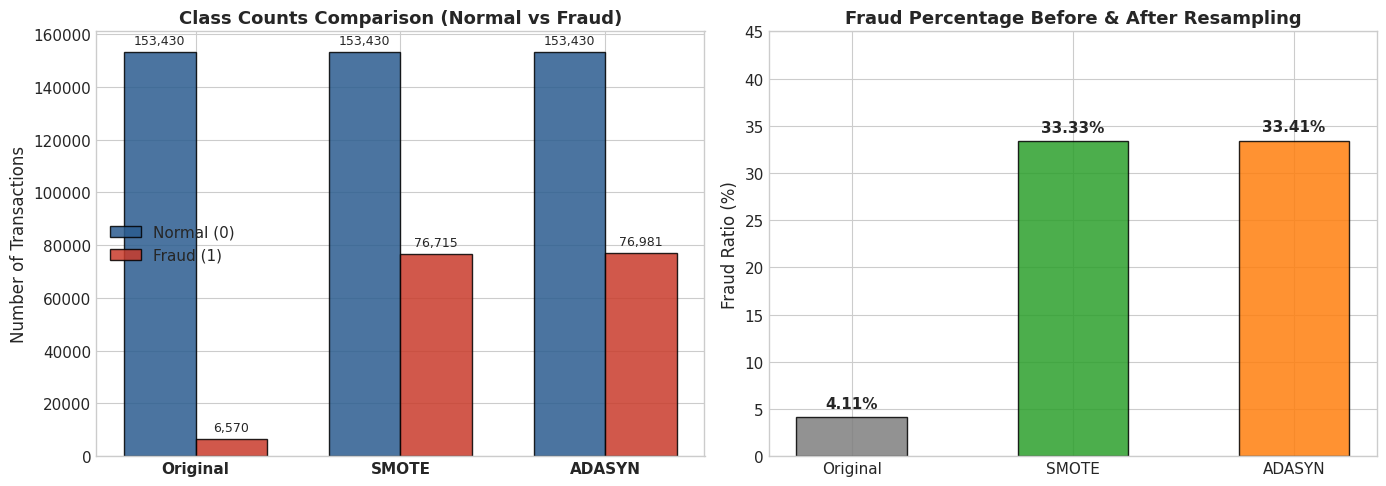

In [5]:
df_report = report_class_distribution(y_train, y_smote, y_adasyn)
print(df_report.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

datasets = df_report["Dataset"].tolist()
normal_counts = df_report["Normal"].tolist()
fraud_counts = df_report["Fraud"].tolist()

x = np.arange(len(datasets))
width = 0.35

ax[0].bar(x - width/2, normal_counts, width, label="Normal (0)", color="#2b5c8f", edgecolor="black", alpha=0.85)
ax[0].bar(x + width/2, fraud_counts, width, label="Fraud (1)", color="#c93b2b", edgecolor="black", alpha=0.85)
ax[0].set_xticks(x)
ax[0].set_xticklabels(datasets, fontsize=11, fontweight="bold")
ax[0].set_ylabel("Number of Transactions", fontsize=12)
ax[0].set_title("Class Counts Comparison (Normal vs Fraud)", fontsize=13, fontweight="bold")
ax[0].legend(fontsize=11)
for i in range(len(datasets)):
    ax[0].text(i - width/2, normal_counts[i] + 3000, f"{normal_counts[i]:,}", ha="center", fontsize=9)
    ax[0].text(i + width/2, fraud_counts[i] + 3000, f"{fraud_counts[i]:,}", ha="center", fontsize=9)

ratios = [y_train.mean() * 100, y_smote.mean() * 100, y_adasyn.mean() * 100]
bars = ax[1].bar(datasets, ratios, color=["#7f7f7f", "#2ca02c", "#ff7f0e"], edgecolor="black", width=0.5, alpha=0.85)
ax[1].set_ylabel("Fraud Ratio (%)", fontsize=12)
ax[1].set_title("Fraud Percentage Before & After Resampling", fontsize=13, fontweight="bold")
ax[1].set_ylim(0, 45)
for bar, r in zip(bars, ratios):
    ax[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{r:.2f}%", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

## 5. Kết luận & Bàn giao dữ liệu
1. **SMOTENC & ADASYN** đã giải quyết triệt để sự mất cân bằng dữ liệu: Nâng số lượng mẫu Fraud từ `6,570` mẫu (4.11%) lên hơn `76,700` mẫu (~33.3%).
2. Toàn bộ 4 cờ nhị phân (`is_drain_account`, `is_night_transaction`, `is_large_transaction`, `type_TRANSFER`) được bảo toàn 100% dạng 0/1.
3. Dữ liệu đã được lưu trữ sẵn sàng tại `data/processed/` phục vụ huấn luyện Random Forest (Phase 03) và XGBoost / Autoencoder (Phase 04).